# t-test

> 📈 **Задача**
>
> В Avito хотят перейти с одной СУБД на другую. Главным критерием для перехода является "затраченное время в сутках на загрузку новых данных". Если раньше для ежедневного обновления базы требовалось в среднем 10 часов, то хочется найти новую СУБД, в которой все это будет происходить быстрее, чем за 7 часов.
>
> Для этого было принято решение перенести все данные на новую тестируемую СУБД. В течение одной недели каждый день мы посчитаем время загрузки данных, и если в среднем на обновление будет уходить меньше 7 часов, то мы полностью перейдем на новую СУБД. Ваша задача придумать, как проверить гипотезу о том, что новая СУБД лучше старой.
> ___
> *СУБД - система управления базами данных*
>
> *БД - база данных*

Получилась выборка:

- `[6.9, 6.45, 6.32, 6.88, 6.09, 7.13, 6.76]` &mdash; время загрузки в новую БД по дням в часах.

Для начала переформулируем условие на языке математики: есть выборка
- $X_1, X_2, ..., X_7$ &mdash; время загрузки в часах новых данных в СУБД за каждый день эксперимента
- Еще будем считать, что $X$ из нормального распредения.

In [1]:
from scipy.stats import norm, binom, expon, t, chi2, pareto, ttest_1samp, ttest_ind, sem
from statsmodels.stats.api import CompareMeans, DescrStatsW
from statsmodels.stats.proportion import proportion_confint
import numpy as numpy
from seaborn import histplot
from matplotlib import pyplot
import seaborn

In [2]:
x = numpy.array([6.9, 6.45, 6.32, 6.88, 6.09, 7.13, 6.76])
print(f"Среднее время загрузки в СУБД: {round(x.mean(), 2)}")

Среднее время загрузки в СУБД: 6.65


Наша гипотеза звучит так:

$H_0$: $E \overline{X} \geq 7\ vs.\ H_1: E \overline{X} < 7$



Вспомним про z-критерий.

--- 
**Z-критерий**

$H_0: \mu \leq \mu_0\ vs.\ H_1: \mu > \mu_0$
- Статистика $Z(X) = \sqrt{n}\dfrac{\overline X - \mu_0}{\sqrt{\sigma^2}}$
- При достаточно большом размере выборки $Z(X) \overset{H_0}{\sim} \mathcal{N}(0, 1)$ (по ЦПТ)
- Односторонний критерий: $\left\{Z(X) \geq z_{1 - \alpha} \right\}$
    - p-value = $1 - \Phi(z)$, где z &mdash; реализация статистики $Z(X)$, $\Phi(z)$ &mdash; функция распределения $\mathcal{N}(0, 1)$
- Двусторонний критерий: $\left\{Z(X) \geq z_{1 - \frac{\alpha}{2}} \right\} \bigcup \left\{Z(X) \leq -z_{1 - \frac{\alpha}{2}} \right\} $
    - p-value = $2\cdot \min \left[{\Phi(z), 1 - \Phi(z)} \right]$, где z &mdash; реализация статистики $Z(X)$
---

Тогда надо лишь посчитать следующую статистику: $\sqrt{n}\dfrac{\overline X - 7}{\sqrt{\sigma^2}} \overset{H_0}{\sim} \mathcal{N}(0, 1)$

**Но есть одна проблема: мы не знаем $\sigma^2$**


Так выглядит оценка: $\widehat{\sigma^2} =S^2 = \dfrac{1}{n - 1}\underset{i=1}{\overset{n}{\sum}}(X_i - \overline X)^2$. Она является [несмещенной](https://ru.wikipedia.org/wiki/Несмещённая_оценка) и [состоятельной](https://ru.wikipedia.org/wiki/Состоятельная_оценка) оценкой дисперсии.

In [3]:
# ddof = 1 -- Это значит, что делим не на n, а на n-1 в формуле выше
print(f"Оценка sigma^2: {numpy.var(x, ddof=1)}")

Оценка sigma^2: 0.1367238095238095


Давайте введем новый критерий T'-test, в котором мы подставим:

- $T(X) := \sqrt{n}\dfrac{\overline X - \mu_0}{\sqrt{S^2}} $
- $T(X) \overset{H_0}{\sim} \mathcal{N}(0, 1)$

    
Осталось проверить: **Правда ли что при $H_0$ распределение статистики T &mdash; стандартное нормальное?**


Для этого я предлагаю посмотреть, как на самом деле будет распределена статиcтика $T(X) = \sqrt{n}\dfrac{\overline{X}-\mu_0}{\sqrt{S^2}}$ в задаче, поставленной изначально. 
Для этого будем считать, что выборка $X$ состоит из 7 элементов и $X \sim \mathcal{N}$.

- Мы $M$ раз нагенерируем выборку $X$ и посчитаем каждый раз статиcтику $T(X)$.
- В итоге мы получим выборку размера $M$ для $T(X)$ и сможем построить гистограмму распределения. Отдельно построим распределение $\mathcal{N}(0, 1)$. Если эмпирическое распределение визуально совпадет с теоретическим нормальным, значит все хорошо. А если нет, то так просто мы не можем заменить $\sigma^2$ на $S^2$.
    - Дополнительно посмотрим, что будет, если заменить $T(X)$ на $Z(X)$. На искусственном примере мы знаем дисперсию.

Для этого мы напишем единообразную функцию, которая сможет построить распределение для любой статистики, а не только для $T(X), Z(X)$.

In [4]:
def sample_statistics(
    number_of_experiments, statistic_function, sample_size, sample_distr
):
    """
    Функция для генерации выборки некой статистики statistic_function, построенной по выборке из распределения sample_distr.
    Возвращает выборку размера number_of_experiments для statistic_function.

    Праметры:
        - number_of_experiments: число экспериментов, в каждом из которых мы посчитаем statistic_function
        - statistic_function: статистика, которая принимает на вход выборку из распределения sample_distr
        - sample_size: размер выборки, которая подается на вход statistic_function
        - sample_distr: распределение изначальной выборки, по которой считается статистика
    """
    statistic_sample = []
    for _ in range(number_of_experiments):
        # генерируем number_of_experiments раз выборку
        sample = sample_distr.rvs(sample_size)
        statistic = statistic_function(sample)
        statistic_sample.append(statistic)
    return statistic_sample

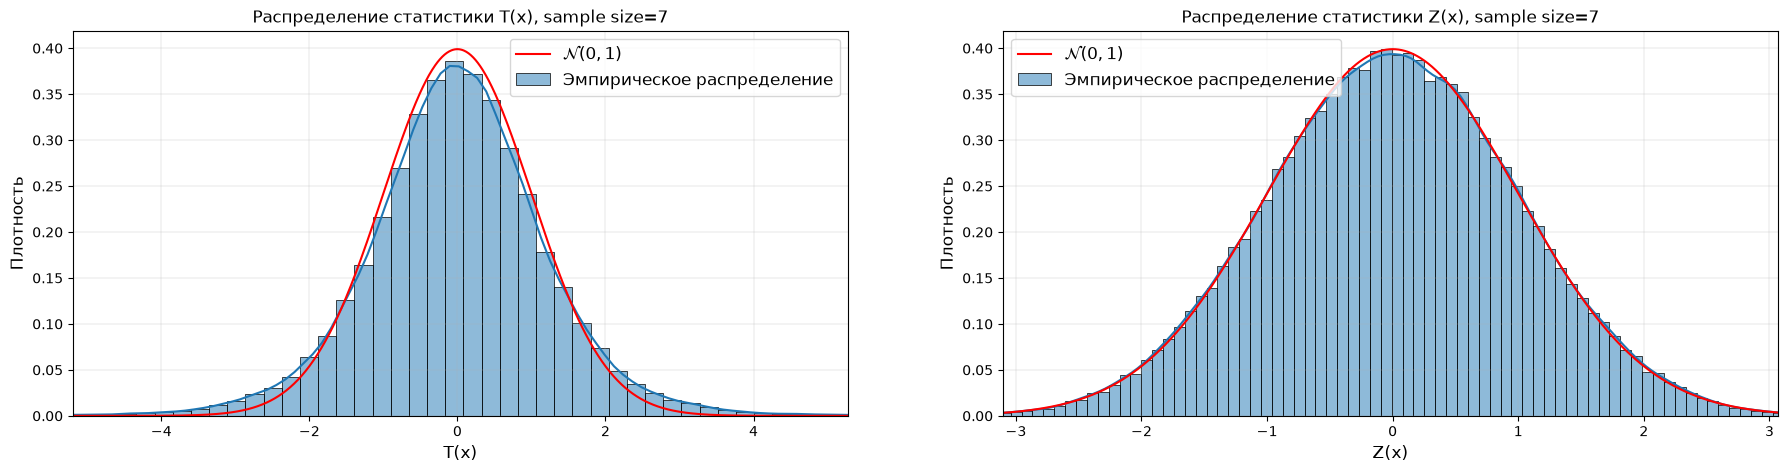

In [5]:
numpy.random.seed(8)

sample_size = 7
M = 100000
sample_distr = norm(loc=5, scale=3)  # Пусть выборка из этого распределения

T_x = (
    lambda sample: numpy.sqrt(sample_size)
    * (numpy.mean(sample) - sample_distr.mean())
    / numpy.std(sample, ddof=1)
)
Z_x = (
    lambda sample: numpy.sqrt(sample_size)
    * (numpy.mean(sample) - sample_distr.mean())
    / sample_distr.std()
)

samples = {
    "T(x)": sample_statistics(
        number_of_experiments=M,
        statistic_function=T_x,
        sample_size=sample_size,
        sample_distr=sample_distr,
    ),
    "Z(x)": sample_statistics(
        number_of_experiments=M,
        statistic_function=Z_x,
        sample_size=sample_size,
        sample_distr=sample_distr,
    ),
}
pyplot.figure(figsize=(22, 5))
for i, name in enumerate(["T(x)", "Z(x)"], start=1):
    pyplot.subplot(1, 2, i)
    current_sample = samples[name]
    l_bound, r_bound = numpy.quantile(current_sample, [0.001, 0.999])
    x = numpy.linspace(l_bound, r_bound, 1000)
    histplot(
        current_sample,
        stat="density",
        bins=100,
        kde=True,
        label="Эмпирическое распределение",
    )
    pyplot.title(
        f"Распределение статистики {name}, sample size={sample_size}", fontsize=12
    )
    pyplot.plot(x, norm(0, 1).pdf(x), label=r"$\mathcal{N}(0, 1)$", color="red")
    pyplot.legend(fontsize=12)
    pyplot.xlabel(name, fontsize=12)
    pyplot.ylabel("Плотность", fontsize=12)
    pyplot.grid(linewidth=0.2)
    pyplot.xlim((l_bound, r_bound))


pyplot.show()

Мы видим, что:
- Z-test тут работает: $\sqrt{n}\dfrac{\overline X - \mu_0}{\sqrt{\sigma^2}} \sim \mathcal{N}(0, 1)$.
- Но вот для $T(X)$ это не так! **Они отличаются! А значит T'-критерий не подходит для изначальной задачи!** 

----

### Почему такое произошло?

При создании критерия есть **2 шага**:
1. Придумать статистику для критерия
    - С этим мы успешно справились, придумав $T(X)$.
2. Понять, как распределена статистика.
    - И вот это самый сложный шаг, который не позволяет использовать любую придуманную статистику. Нужно также понимать ее распределение.
    - И с этим, как мы увидели, мы провалились для $T(X)$. Нормальное распределение не подошло.

Но почему $T(X) = \sqrt{n}\dfrac{\overline X - \mu}{\sqrt{S^2}}$ не распределена нормально, хотя $\sqrt{n}\dfrac{\overline X - \mu}{\sqrt{\sigma^2}} \overset{H_0}{\sim} \mathcal{N}(0, 1)$? Почему при замене $\sigma^2$ на $S^2$ все испортилось? 

**Дело в том, что $S^2$ &mdash; это случайная величина!**

Вспомним, как мы выводили Z-критерий?
1. Мы посчитали, что $\overline X \sim \mathcal{N}(\mu, \sigma^2)$. Из ЦПТ или, в случае выше, из свойств нормального распределения.
2. Далее, все также из свойств этого распределения следует, что если мы вычтем константу или поделим на константу, то нормальное распределение не превратится в другое: поэтому $\sqrt{n}\dfrac{\overline X - \mu_0}{\sqrt{\sigma^2}} \sim \mathcal{N}(0, 1)$.

**Но мы ничего не знаем про** $\dfrac{\overline{X}}{\sqrt{\eta}}$, где $\overline{X} \sim \mathcal{N}, S^2 := \eta \sim P$, где P неизвестно. Мы не знаем пока никаких теорем, которые хоть как-то доказывали, что тут также останется нормальное распределение.

Посмотрим на распределение $\sqrt{S^2}$ на все том же нормальном распределении.

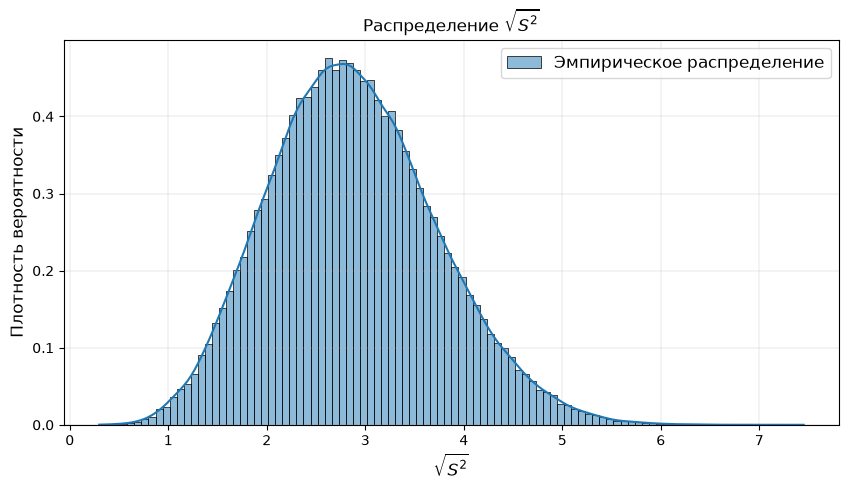

In [6]:
numpy.random.seed(42)

s2 = lambda sample: numpy.std(sample, ddof=1)
s2_sample = sample_statistics(
    number_of_experiments=M,
    statistic_function=s2,
    sample_size=sample_size,
    sample_distr=sample_distr,
)

pyplot.figure(figsize=(10, 5))
pyplot.title(r"Распределение $\sqrt{S^2}$", fontsize=12)
histplot(
    s2_sample, kde=True, stat="density", bins=100, label="Эмпирическое распределение"
)
pyplot.legend(fontsize=12)
pyplot.xlabel(r"$\sqrt{S^2}$", fontsize=12)
pyplot.ylabel("Плотность вероятности", fontsize=12)
pyplot.grid(linewidth=0.2)
pyplot.show()

Мы видим, что оно не симметрично и непонятно как распределено. Поэтому, когда мы некую величину из нормального распределения делим на несимметричное непонятное распределение, мы и получаем, что наша статистика $T$ не из нормального распределения.

Выведем критерий, который поможет решить изначальную задачу

## T-test

Давайте решим проблему шага 2 в создании критерия и найдем распределение статистики $T = \sqrt{n}\dfrac{\overline X - \mu_0}{\sqrt{S^2}}$. Для того, чтобы это узнать, нам потребуется несколько фактов:

1. Пусть $X_1 \ldots X_n \sim \mathcal{N}(\mu, \sigma^2)$

2. Пусть $\xi_1 \ldots \xi_n \sim \mathcal{N}(0, 1)$. Тогда $\eta=\xi_1^2 +\ ... +\xi_n^2 \sim \chi^2_n$, &mdash; [**хи-квадрат распределение с $n$ степенями свободы**](https://ru.wikipedia.org/wiki/Распределение_хи-квадрат).
    - Тогда $\underset{i=1}{\overset{n}{\sum}}\left(\xi_i - \overline \xi \right)^2 \sim \chi^2_{n-1}$. [Док-во](https://en.wikipedia.org/wiki/Cochran%27s_theorem).

    - $S^2_X = \dfrac{1}{n - 1}\underset{i=1}{\overset{n}{\sum}}(X_i - \overline X)^2 $

    - $\xi_i := \dfrac{X_i - \mu}{\sigma} \sim \mathcal{N}(0, 1)$. Тогда $S^2_{\xi} = \dfrac{1}{\sigma^2}S^2_X$.
<!--     $$\begin{align}
    S^2_{\xi} &= \dfrac{1}{n - 1}\underset{i=1}{\overset{n}{\sum}}\left(\xi_i - \overline \xi \right)^2 =
            \dfrac{1}{n - 1}\underset{i=1}{\overset{n}{\sum}} \left(\dfrac{X_i-\mu}{\sigma} - \underset{i=1}{\overset{n}{\sum}}\left[\dfrac{X_i-\mu}{n\sigma}\right] \right)^2 = \\
             &= \dfrac{1}{n - 1}\underset{i=1}{\overset{n}{\sum}} \left(\dfrac{X_i}{\sigma} - \dfrac{\mu}{\sigma} - \underset{i=1}{\overset{n}{\sum}}\left[\dfrac{X_i}{n\sigma}\right] + \dfrac{n\mu}{n\sigma} \right)^2 =\\
             &= \dfrac{1}{n - 1}\underset{i=1}{\overset{n}{\sum}} \left(\dfrac{X_i}{\sigma} -\dfrac{\overline X_i}{\sigma} \right)^2 = \dfrac{1}{\sigma \cdot(n - 1)}\underset{i=1}{\overset{n}{\sum}} \left(X_i - \overline X_i \right)^2 = \dfrac{1}{\sigma}S^2_X
    \end{align}
    $$ -->
    
    - А значит
  $$ \frac{(n-1)S_X^2}{\sigma^2} = \sum_{i=1}^{n}\left(\xi_i-\overline{\xi}\right)^2 \sim \chi^2_{n-1}. $$

3. Пусть $\xi \sim \mathcal{N}(0, 1), \eta \sim \chi^2_k$ и $\xi$ с $\eta$ независимы. Тогда статистика $\zeta = \dfrac{\xi}{\sqrt{\eta/k}} \sim t_{k}$ &mdash; из [распределения Стьюдента](https://ru.wikipedia.org/wiki/Распределение_Стьюдента) с k степенями свободы.
 
    - $\xi := \sqrt{n}\dfrac{\overline X - \mu_0}{\sigma} \sim \mathcal{N}(0, 1)$
    - $\eta := \dfrac{(n - 1)\cdot S^2_X}{\sigma^2} \sim \chi^2_{n-1}$
    - $\xi$ и $\eta$ [независимы](https://math.stackexchange.com/questions/4165803/overlinex-and-s2-are-independent)
    - Тогда
    $$\begin{align}
        T = \sqrt{n}\dfrac{\overline X - \mu_0}{\sqrt{S^2}} = \frac{\sqrt{n}\dfrac{\overline X - \mu_0}{\sigma}}{\sqrt{\dfrac{(n - 1)\cdot S^2_X}{(n - 1)\sigma^2}}} = \dfrac{\xi}{\sqrt{\dfrac{\eta}{n-1}}} \sim t_{n - 1}
    \end{align}$$

**Итого:**

Придуманная нами статистика $T = \sqrt{n}\dfrac{\overline X - \mu_0}{\sqrt{S^2}} \sim t_{n - 1}$ &mdash; взята из распределения Стьюдента с n - 1 степенью свободы. **Но только в случае, если изначальная выборка из нормального распределения!**

Теперь нам достаточно данных, чтобы построить критерий для нашей изначальной задачи:

### T-test, критерий

$H_0: \mu =\mu_0, X \sim \mathcal{N}\ vs.\ H_1: \mu > \mu_0$ или $X$ не из нормального распределения
- Статистика $T(X) = \sqrt{n}\dfrac{\overline X - \mu_0}{\sqrt{S^2}}$
- $T(X)  \sim t_{n - 1}$
- Односторонний критерий: $\left\{T(X) \geq t_{n-1, 1 - \alpha} \right\}$
    - p-value = $1 - \tau_{n-1}(z)$, где z &mdash; реализация статистики $T(X)$, $\tau_{n-1}(z)$ &mdash; функция распределения $t_{n - 1}$
- Двусторонний критерий: $\left\{T(X) \geq t_{n-1, 1 - \frac{\alpha}{2}} \right\} \bigcup \left\{T(X) \leq -t_{n-1, 1 - \frac{\alpha}{2}} \right\} $
    - p-value = $2\cdot \min \left[{\tau_{n-1}(z), 1 - \tau_{n-1}(z)} \right]$, где z &mdash; реализация статистики $T(X)$
---

Протестируем все наши теоретические исследования на практике

#### Python-библиотеки:
- `scipy.stats.chi2(df=N)` &mdash; [библиотека](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html) для распределения хи-квадрат с N степенями свободы.
- `scipy.stats.t(df=N)` &mdash; [библиотека](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html) для распределения Стьюдента с N степенями свободы.
- `scipy.stats.ttest_1samp`  &mdash; [реализованный T-критерий](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_1samp.html) в Python


Для начала посмотрим на распределение Хи квадрат и на распределение $\eta$.

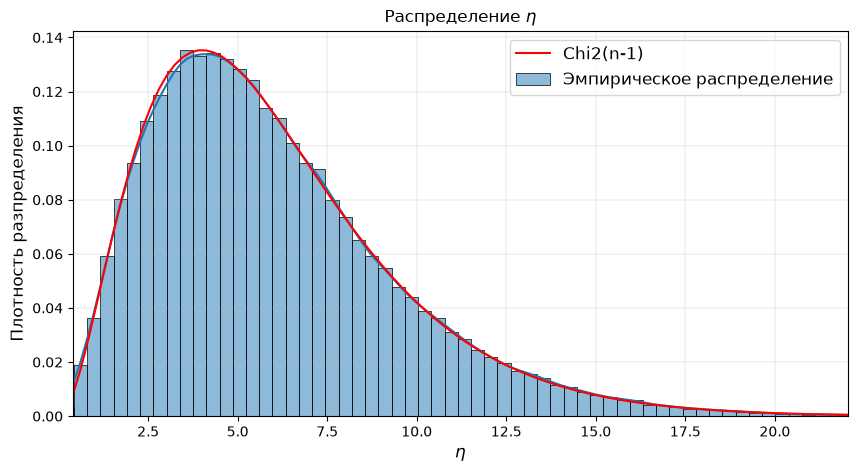

In [ ]:
numpy.random.seed(42)

eta_statistic = (
    lambda sample: numpy.var(sample, ddof=1) * (sample_size - 1) / sample_distr.var()
)
eta_sample = sample_statistics(
    number_of_experiments=M,
    statistic_function=eta_statistic,
    sample_size=sample_size,
    sample_distr=sample_distr,
)
chi2_distr = chi2(df=sample_size - 1)
pvalue = chi2_distr.cdf(eta_sample)  # распределение chi2

l_bound, r_bound = numpy.quantile(eta_sample, [0.001, 0.999])
x = numpy.linspace(l_bound, r_bound, 100)

pyplot.figure(figsize=(10, 5))
pyplot.title(r"Распределение $\eta$", fontsize=12)
histplot(
    eta_sample, stat="density", bins=100, kde=True, label="Эмпирическое распределение"
)
pyplot.plot(x, chi2_distr.pdf(x), label="Chi2(n-1)", color="red")
pyplot.legend(fontsize=12)
pyplot.xlabel(r"$\eta$", fontsize=12)
pyplot.ylabel("Плотность разпределения", fontsize=12)
pyplot.xlim(l_bound, r_bound)
pyplot.grid(linewidth=0.2)
pyplot.show()

В этот раз совпало!

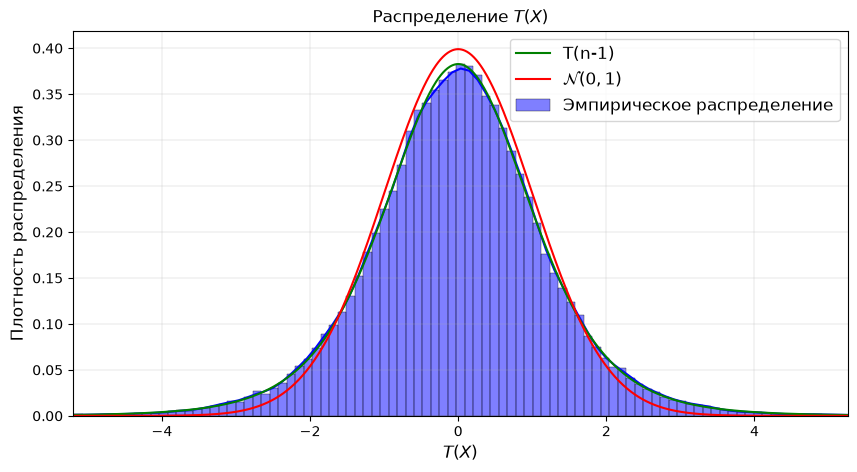

In [ ]:
numpy.random.seed(42)

T_X = (
    lambda sample: numpy.sqrt(sample_size)
    * (numpy.mean(sample) - sample_distr.mean())
    / numpy.std(sample, ddof=1)
)

T_sample = sample_statistics(
    number_of_experiments=M,
    statistic_function=T_X,
    sample_size=sample_size,
    sample_distr=sample_distr,
)

T_dist = t(df=sample_size - 1)

l_bound, r_bound = numpy.quantile(T_sample, [0.001, 0.999])
x = numpy.linspace(l_bound, r_bound, 1000)

pyplot.figure(figsize=(10, 5))
pyplot.title("Распределение $T(X)$", fontsize=12)
histplot(
    T_sample,
    stat="density",
    bins=200,
    kde=True,
    label="Эмпирическое распределение",
    color="blue",
)
pyplot.plot(x, T_dist.pdf(x), c="green", label="T(n-1)")
pyplot.plot(x, norm(0, 1).pdf(x), c="red", label=r"$\mathcal{N}(0, 1)$")
pyplot.legend(fontsize=12)
pyplot.xlabel("$T(X)$", fontsize=12)
pyplot.ylabel("Плотность распределения", fontsize=12)
pyplot.xlim((l_bound, r_bound))
pyplot.grid(linewidth=0.2)
pyplot.show()

Здесь видно, что распределение Стьюдента практически идеально описывает данные, в то время как нормальное распределение более "центрировано": площадь в центре больше.

Теперь, как вызвать встроенный t-test в Питоне:

In [ ]:
# Как вызывать критерий
ttest_1samp(norm(loc=0, scale=1).rvs(100), popmean=-1, alternative="greater")

TtestResult(statistic=np.float64(11.510815172646131), pvalue=np.float64(2.87594512652606e-20), df=np.int64(99))

### Доверительный интервал

2 метода вывода доверительного интервала.

#### 1 метод

Вспомним определение:

> Пусть есть статистика $Q$ и критерий $\psi(Q)$ для проверки гипотезы $H_0: \theta = m$ уровня значимости $\alpha$.
>
> Тогда доверительный интервал для $\theta$ уровня доверия $1 - \alpha$: множество таких m, что критерий $\psi(Q)$ не отвергает для них $H_0$.


Пусть $\mu$ &mdash; истинное среднее выборки. Мы также знаем, что при $H_0: \sqrt{n}\dfrac{\overline X - m}{\sqrt{S^2}} \sim t_{n - 1}$.

Нас интересуют такие $m$, что:  $\left\{-t_{n-1, 1 - \frac{\alpha}{2}} < \sqrt{n}\dfrac{\overline X - m}{\sqrt{S^2}} < t_{n-1, 1 - \frac{\alpha}{2}} \right\}$, в этом случае критерий не отвергнется.

Распишем, чтобы в центре осталось только $m$: $\left\{\overline X - \dfrac{t_{n - 1, 1 - \alpha/2} \sqrt{S^2}}{\sqrt{n}} < m < \overline X + \dfrac{t_{n - 1, 1 - \alpha/2} \sqrt{S^2}}{\sqrt{n}}\right\}$. А значит наш доверительный интервал: $CI_{\mu} = \left(\overline X \pm \dfrac{t_{n - 1, 1 - \alpha/2} \sqrt{S^2}}{\sqrt{n}} \right),$ где $S^2 = \dfrac{1}{n - 1}\underset{i=1}{\overset{n}{\sum}}(X_i - \overline X)^2$.

### 2 метод

Докажем через [классическое определение](https://ru.wikipedia.org/wiki/Доверительный_интервал#Определение) доверительного интервала.

> Доверительным интервалом для параметра $\theta$ уровня доверия $1 - \alpha$ является пара статистик $L(X), R(X)$, таких, что $P(L(X) < \theta < R(X)) = 1 - \alpha$.

$$\begin{align}
    &T(X) = \sqrt{n}\dfrac{\overline X - \mu}{\sqrt{S^2}} \sim t_{n - 1} \Rightarrow \\
    &P\left(-t_{n - 1, 1-\alpha/2} < \sqrt{n}\dfrac{\overline X - \mu}{\sqrt{S^2}} < t_{n - 1, 1-\alpha/2} \right) = 1 - \alpha \Leftrightarrow \\
    &P\left(\overline X - \dfrac{t_{n - 1, 1 - \alpha/2} \sqrt{S^2}}{\sqrt{n}}  < \mu < \overline X + \dfrac{t_{n - 1, 1 - \alpha/2} \sqrt{S^2}}{\sqrt{n}} \right) = 1 - \alpha
\end{align}
$$


А значит $CI_{\mu} = \left(\overline X \pm \dfrac{t_{n - 1, 1 - \alpha/2} \sqrt{S^2}}{\sqrt{n}} \right)$. 

*Доказательства в обоих случаях практически идентичны.*


В Питоне для построения есть специальная функция:

In [10]:
sample = norm(loc=10, scale=2).rvs(100)

In [ ]:
# sem -- standart error of the mean, sem = sqrt(S^2)/sqrt(n)
left_bound, right_bound = t.interval(
    confidence=0.95, loc=numpy.mean(sample), df=len(sample) - 1, scale=sem(sample)
)
print(f"CI = [{round(left_bound, 2)}, {round(right_bound, 2)}]")

CI = [9.62, 10.39]


-----

Вернемся к изначальной задаче. 
> 📈 **Задача**
>
> В нашей компании хотят перейти с одной СУБД на другую. Главным критерием для переходя является "затраченное время в сутках на загрузку новых данных". Если раньше для ежедневного обновления базы требовалось в среднем 10 часов, то хочется найти новую СУБД, в которой все это будет происходить бывстрее, чем за 7 часов.
>
> Для этого было принято решение перенести все данные на новую тестируемую СУБД. В течение одной недели каждый день мы посчитаем время загрузки данных, и если в среднем на обновление будет уходить меньше 7 часов, то мы полностью перейдем на новую СУБД. Ваша задача придумать, как проверить гипотезу о том, что новая СУБД лучше старой.

Получилась выборка:

- `[6.9, 6.45, 6.32, 6.88, 6.09, 7.13, 6.76]` &mdash; время загрузки в новую БД по дням в часах.

Для начала переформулируем условие на языке математики: есть выборка
- $X_1, X_2, ..., X_7$ &mdash; время загрузки в часах новых данных в СУБД за каждый день эксперимента
- Еще будем считать, что $X$ из нормального распредения.

$H_0$: $E \overline{X} \geq 7\ vs.\ H_1: E \overline{X} < 7$



Мы уже знаем, что если выборка нормальна, то мы можем использовать T-test. Тогда



In [12]:
X = numpy.array([6.9, 6.45, 6.32, 6.88, 6.09, 7.13, 6.76])

In [ ]:
result = ttest_1samp(X, popmean=7, alternative="less")
print(result)
print(result.confidence_interval(confidence_level=0.95))

TtestResult(statistic=np.float64(-2.524793468045073), pvalue=np.float64(0.02249742917295712), df=np.int64(6))
ConfidenceInterval(low=np.float64(-inf), high=np.float64(6.918715582008102))


Мы видим, что на уровне значимости 2.5% критерий отвергся, а значит переход на новую СУБД удовлетворяет условиям: загрузка быстрее 7 часов!
Построим теперь доверительный интервал, чтобы понять, в каких границах у нас будет эффект.

In [ ]:
left_bound, right_bound = t.interval(
    confidence=0.95, loc=numpy.mean(X), df=len(X) - 1, scale=sem(X)
)
print(f"CI = [{round(left_bound, 2)}, {round(right_bound, 2)}]")

CI = [6.31, 6.99]


В среднем загрузка будет от 6 до 7 часов.

----

Так, мы научились решать задачу оценки среднего выборки, когда дисперсия неизвестна, но выборка из нормального распределения. Теперь научимся решать следующую задачу:


> 📈 **Задача**
>
> Вы придумали идею для стартапа в Москве, где курьеры собирают заказы для клиентов и отвозят им на дом. Маржа от заказа в вашем стартапе &mdash; X ₽, а стоимость работы курьера &mdash; 1К ₽.
Специфика вашего стартапа такова, что есть большой риск возврата без оплаты. С учетом стоимостей, инвесторы готовы проспонсировать вам инфраструктуру и привлечение клиентов, если вы покажете, что у вас будет прибыль.
>
> Из данных у вас есть принесенные деньги от каждого пользователя. Иногда положительная величина, иногда отрицательная.

Переформулируем задачу на языке статистики:
- $X_1, X_2, ..., X_N$ &mdash; выборка прибыли от пользователя.

$H_0$: $E \overline{X} \leq 0\ vs.\ H_1: E \overline{X} > 0$

Посмотрим на данные:

In [ ]:
profits = numpy.loadtxt("profit_from_user.out", delimiter=",")
print(profits[:100])

[-718.  657.  693.  391. -644.  421.  265. -108. 1956. -684. -753. -725.
 -341. -796. -662.  257. -719. 5184. -739. -291. -427.  283.   10.  500.
 -713. -458.   60. -756.  333. -537. -744.  254. -555. -780. -329. -560.
  936. -742. -784.  213.  299. -678. -736.   24.  264.  293. -490. 2667.
 -605. -799. -797. -743.  347. -718. -508. -766. 1395.  392.  -62. -510.
  237. -785. -745. -781. 3232. -727.  204. 2987.  244. -757.  -78.   10.
  364.   -7. -440.  520.  203.  282.  685.  589. -724.  -48.  263. -457.
 -796. -708. -798.  488. -677. -690.  786. -770.  659. -679. -309. -731.
  288. 1047. -796. -721.]


In [16]:
print(f"average profit = {profits.mean()}")
print(f"n = {profits.shape[0]}")

average profit = 58.4868
n = 5000


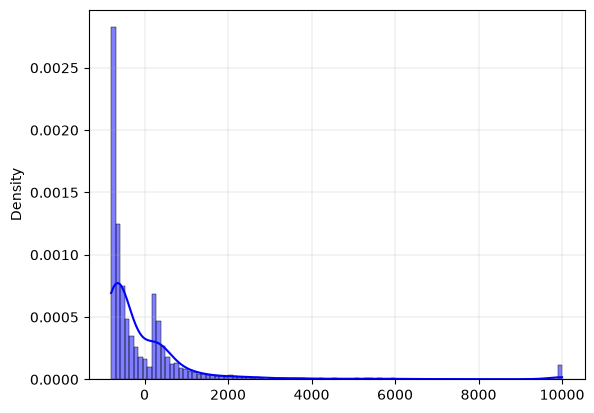

In [21]:
histplot(
    profits,
    stat="density",
    bins=100,
    kde=True,
    label="Эмпирическое распределение",
    color="blue",
)
pyplot.grid(linewidth=0.2)


В отличие от предыдущей задачи тут 2 отличия:
- Изначальная выборка не из нормального распределения
- Выборка достаточно крупная: не 7 элементов, а уже 5000.

Так, а что мы уже умеем решать?


|                          | маленькая выборка | большая выборка |
|--------------------------|-------------------|-----------------|
| нормальное распределение | t-test            | t-test          |
| любое распределение      |                   |                 |

А сейчас мы выведем критерий для ячейки: "любое распределение, большая выборка". Мы снова будем выводить распределение для $T(X)$ статистики.


## T'-test

Вспомним, что у нас изначально была идея в Z-тесте вместо статистики Z, в которой дисперсия известна, использовать критерий T, где дисперсия оценена на данных. И использовать нормальное распределение. Только в первой задаче этот критерий нам не помог. Но что, если бы выборка была большой? Могли бы мы использовать нормальное распределение для приближения?


1. Будем рассматривать ту же статистику $T = \sqrt{n}\dfrac{\overline X - \mu_0}{\sqrt{S^2}}$
2. $\xi := \sqrt{n}\dfrac{\overline X - \mu_0}{\sqrt{\sigma^2}} \stackrel{d}{\rightarrow} \mathcal{N}(0, 1)$. По ЦПТ сходимость есть только по [распределению](https://en.wikipedia.org/wiki/Convergence_in_distribution).
3. Тогда $T = \sqrt{n}\dfrac{\overline X - \mu_0}{\sqrt{S^2}} = \xi \cdot \sqrt{\dfrac{\sigma^2}{S^2}}$. Обозначим $\phi := \sqrt{\dfrac{\sigma^2}{S^2}}$
    - Помните, что $S^2$ &mdash; лучшая оценка для дисперсии? Все дело в том, что она является [состоятельной оценкой](https://ru.wikipedia.org/wiki/Состоятельная_оценка) $\sigma^2$. По-другому это можно записать так: $S^2$ [сходится по вероятности](https://en.wikipedia.org/wiki/Convergence_of_random_variables#Convergence_in_probability) к $\sigma^2$. То есть $S^2  \stackrel{p}{\rightarrow} \sigma^2$ 
    - А в этом случае существует [теорема](https://en.wikipedia.org/wiki/Continuous_mapping_theorem), утверждающая, что $\phi = \dfrac{\sigma^2}{S^2}  \stackrel{p}{\rightarrow} 1$.
4. $T = \xi \cdot \phi$.
    - $\xi \stackrel{d}{\rightarrow} \mathcal{N}(0, 1)$
    - $\phi  \stackrel{p}{\rightarrow} 1$
    - И тут вступает в силу еще одна [теорема](https://en.wikipedia.org/wiki/Slutsky%27s_theorem): $T = \xi \cdot \phi \stackrel{d}{\rightarrow} 1\cdot \mathcal{N}(0, 1)$. Та же сходимость, что и в ЦПТ!
    - **То есть статистика $T$ точно также нормально распределена!**
    
    
Итого, если выборка большая, то мы можем считать, что $T(X) \overset{H_0}{\sim} \mathcal{N}(0, 1)$.

---

Заметим, что в случае "нормальное распределение, большая выборка" работают сразу 2 критерия: t-test и t'-test. Это значит, что если $T(X) \overset{H_0}{\sim} t_{n - 1}$ и $T(X) \overset{H_0}{\sim} \mathcal{N}(0, 1)$, то $t_{n - 1} \approx \mathcal{N}(0, 1)$.
- Формально же, если степень свободы в t-распределении равна бесконечности, то это нормальное распределение! $\lim_{n\rightarrow \infty}t_{n} = \mathcal{N}(0, 1)$

А если $t_{n - 1} \approx \mathcal{N}(0, 1)$, то мы вместо T'-критерия мы можем использовать T-критерий! **Из того, что мы теоретически можем использовать T'-test, на практике мы можем использовать и T-test!**

---

А значит мы заполнили еще 1 ячейку в таблице:

|                          | маленькая выборка | большая выборка |
|--------------------------|-------------------|-----------------|
| нормальное распределение | t-test            | t-test, t'-test |
| любое распределение      |                   | t'-test, t-test |


### T'-test, критерий

$H_0: \mu =\mu_0\ vs.\ H_1: \mu > \mu_0$
- Статистика $T(X) = \sqrt{n}\dfrac{\overline X - \mu_0}{\sqrt{S^2}}$
- При достаточно большом размере выборки $T(X) \overset{H_0}{\sim} \mathcal{N}(0, 1)$ (по ЦПТ и куче вспомогательных теорем)
- Односторонний критерий: $\left\{T(X) \geq z_{1 - \alpha} \right\}$
    - p-value = $1 - \Phi(z)$, где z &mdash; реализация статистики $T(X)$, $\Phi(z)$ &mdash; функция распределения $\mathcal{N}(0, 1)$
- Двусторонний критерий: $\left\{T(X) \geq z_{1 - \frac{\alpha}{2}} \right\} \bigcup \left\{T(X) \leq -z_{1 - \frac{\alpha}{2}} \right\} $
    - p-value = $2\cdot \min \left[{\Phi(z), 1 - \Phi(z)} \right]$, где z &mdash; реализация статистики $Z(X)$
---


Проверим наш критерий на крупных выборках:

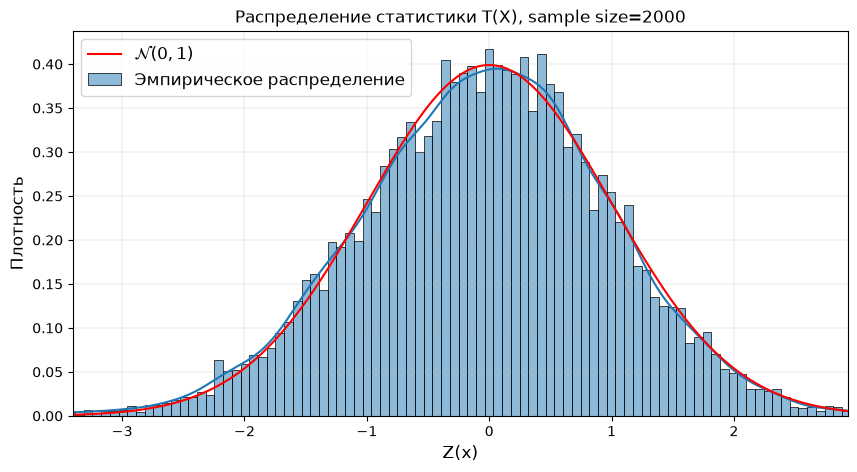

In [ ]:
numpy.random.seed(8)

sample_size = 2000
M = 10000
sample_distr = expon(loc=5, scale=300)

T_X = (
    lambda sample: numpy.sqrt(sample_size)
    * (numpy.mean(sample) - sample_distr.mean())
    / numpy.std(sample, ddof=1)
)
T_sample = sample_statistics(
    number_of_experiments=M,
    statistic_function=T_X,
    sample_size=sample_size,
    sample_distr=sample_distr,
)
pyplot.figure(figsize=(10, 5))
l_bound, r_bound = numpy.quantile(T_sample, [0.001, 0.999])

x = numpy.linspace(l_bound, r_bound, 1000)
pyplot.title(f"Распределение статистики T(X), sample size={sample_size}", fontsize=12)
histplot(
    T_sample, label="Эмпирическое распределение", kde=True, bins=100, stat="density"
)
pyplot.plot(x, norm(0, 1).pdf(x), label=r"$\mathcal{N}(0, 1)$", color="red")
pyplot.legend(fontsize=12)
pyplot.xlabel(f"{name}", fontsize=12)
pyplot.ylabel("Плотность", fontsize=12)
pyplot.xlim(l_bound, r_bound)
pyplot.grid(linewidth=0.2)
pyplot.show()

Мы видим, что распределения совпали! А на нормальном распределении, где в первый раз были различия на маленькой выборке?

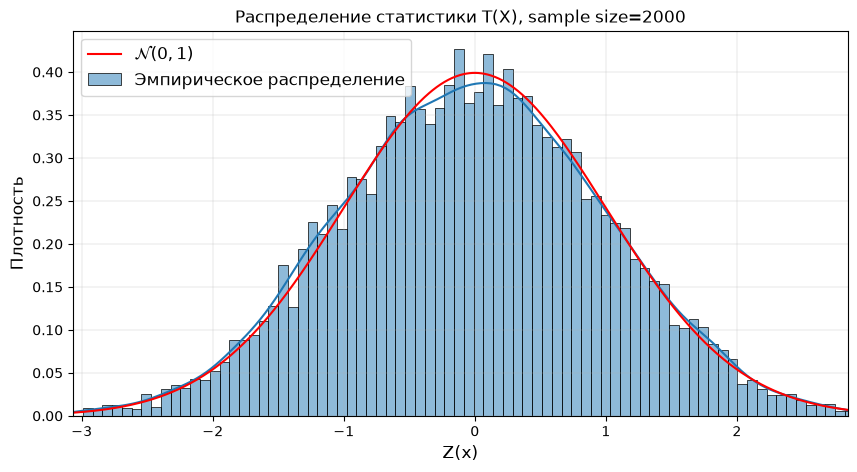

In [ ]:
numpy.random.seed(8)

sample_size = 2000
M = 10000
sample_distr = norm(loc=5, scale=300)

T_X = (
    lambda sample: numpy.sqrt(sample_size)
    * (numpy.mean(sample) - sample_distr.mean())
    / numpy.std(sample, ddof=1)
)
T_sample = sample_statistics(
    number_of_experiments=M,
    statistic_function=T_X,
    sample_size=2000,
    sample_distr=sample_distr,
)
pyplot.figure(figsize=(10, 5))
l_bound, r_bound = numpy.quantile(T_sample, [0.001, 0.999])

x = numpy.linspace(l_bound, r_bound, 1000)
pyplot.title(f"Распределение статистики T(X), sample size={sample_size}", fontsize=12)
histplot(
    T_sample, label="Эмпирическое распределение", kde=True, bins=100, stat="density"
)
pyplot.plot(x, norm(0, 1).pdf(x), label=r"$\mathcal{N}(0, 1)$", color="red")
pyplot.legend(fontsize=12)
pyplot.xlabel(f"{name}", fontsize=12)
pyplot.ylabel("Плотность", fontsize=12)
pyplot.xlim(l_bound, r_bound)
pyplot.grid(linewidth=0.2)
pyplot.show()

Тоже самое: статистика из нормального распределения! То есть в первый раз нам не повезло, что размер выборки был маленьким(

### Доверительный интервал

Выводится также, как и у t-test:

$CI_{\mu} = \left(\overline X \pm \dfrac{z_{1 - \alpha/2} \sqrt{S^2}}{\sqrt{n}} \right)$.


Решим исходную задачу

In [ ]:
sample = expon(scale=300).rvs(2000)  # E sample = scale = 300
left_bound, right_bound = norm.interval(
    confidence=0.95, loc=numpy.mean(sample), scale=sem(sample)
)
print(f"CI = [{round(left_bound, 2)}, {round(right_bound, 2)}]")

CI = [281.15, 306.43]


----

Решим исходную задачу!

In [ ]:
left_bound, right_bound = norm.interval(
    confidence=0.95, loc=numpy.mean(profits), scale=sem(profits)
)
print(f"CI = [{round(left_bound, 2)}, {round(right_bound, 2)}]")

CI = [14.04, 102.94]


Да, выручка положительна! Значит мы нашли инвесторов для нашего стартапа :)

Единственное но: **а правда ли, что наша выборка достаточно большая? И T'-test тут работает?** 

## Какой критерий в итоге использовать на практике? T-test или T'-test?

Для начала определимся, когда какой критерий лучше использовать?

1. Если выборка размера 60, то уже $t_{59} \approx \mathcal{N}(0, 1)$. 
    - Посмотрим на распределения Стьюдента и нормального:

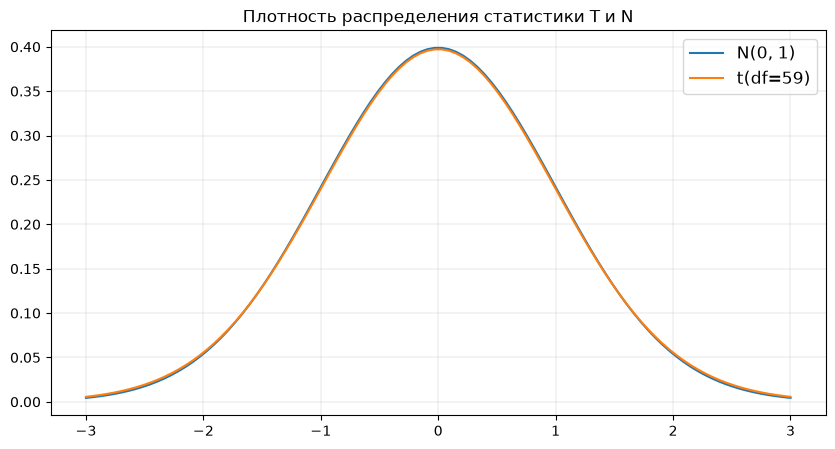

In [ ]:
df = 59
t_dist = t(df=df)
z_dist = norm(loc=0, scale=1)

x = numpy.linspace(-3, 3, 100)
pyplot.figure(figsize=(10, 5))
pyplot.title(f"Плотность распределения статистики T и N", fontsize=12)
pyplot.plot(x, z_dist.pdf(x), label="N(0, 1)")
pyplot.plot(x, t_dist.pdf(x), label=f"t(df={df})")
pyplot.legend(fontsize=12)
pyplot.grid(linewidth=0.2)
pyplot.show()

- Мы видим, что эти 2 распределения визуально полностью совпадают, поэтому неважно, как посчитать: статистика $T\sim \mathcal{N}(0, 1)$ или $T\sim t_n$.
- **Но это не значит, что с N=60 T-test/T'-test работают корректно!** Если выборка не из нормального рапределения, они оба могут все еще ошибаться.

2. Если выборка меньше 60, то безопасней использовать t-test, нежели t'-test.
    - **У T-test FPR всегда будет меньше, чем у T'-test**. 
        - На FPR влияет процент случаев `pvalue < alpha`. У t-test pvalue $\geq$ t'-test pvalue.
        - `pvalue = t_distr.cdf(x)` или `pvalue = norm_dist.cdf(x)`. Поэтому, чем тяжелее хвост у распределения, тем больше p-value. А теперь посмотрим на примере:

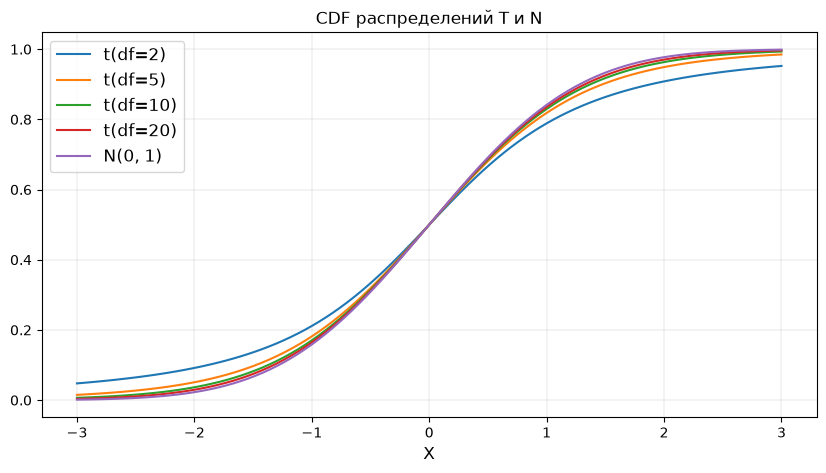

In [ ]:
df_array = [2, 5, 10, 20]
x = numpy.linspace(-3, 3, 100)

pyplot.figure(figsize=(10, 5))
pyplot.title(f"CDF распределений T и N", fontsize=12)
for df in df_array:
    t_dist = t(df=df)
    pyplot.plot(x, t_dist.cdf(x), label=f"t(df={df})")

z_dist = norm(loc=0, scale=1)
pyplot.plot(x, z_dist.cdf(x), label="N(0, 1)")
pyplot.legend(fontsize=12)
pyplot.xlabel("X", fontsize=12)
pyplot.grid(linewidth=0.2)
pyplot.show()

Как видно на графике, чем меньше степень свободы, тем выше линия на графике (при x < 0), а значит и больше cdf при фиксированном x. Поэтому и p-value будет больше.


- Распределение Стьюдента с бесконечностью степеней свободы &mdash; это нормальное распределение: $t_{\infty} = \mathcal{N}(0, 1)$. Поэтому `norm(0, 1).cdf(x) = t_distr(df=infinity).cdf(x) < t_distr(df=N).cdf(x)`.

Поэтому, если выборка небольшая, безопаснее использовать t-test. Но все еще не факт, что ваш критерий будет валиден!

---

Посмотрим еще раз на табличку 

|                          | маленькая выборка | большая выборка |
|--------------------------|-------------------|-----------------|
| нормальное распределение | t-test            | t-test, t'-test |
| любое распределение      |                   | t'-test, t-test |

Мы видим, что мы везде можем использовать t-test (а t'-test не всегда), и в случае маленьких выборок он безопаснее. **Поэтому t-test и стал намного более популярным, чем t'-test**. Но t'-test на практике может быть тоже полезен: 
- Не надо думать при реализации о степенях свободы.
- Написать такой критерий на SQL будет сильно проще: вы можете использовать табличные значения в коде, чтобы понять, отвергся ли критерий.
- Делать различные теоретические вычисления проще. 
- В нем сложнее ошибиться при реализации.

